# Piscis, layer by layer

A visual walk through **`mini_piscis.py`** — the single-file, NumPy-only port of
[Piscis](https://github.com/zjniu/Piscis)'s `20251212` spot-detection model in
this repo, and a sibling to
[`mini_cellpose_walkthrough.ipynb`](mini_cellpose_walkthrough.ipynb) /
[`mini_stardist_walkthrough.ipynb`](mini_stardist_walkthrough.ipynb) /
[`mini_instanseg_walkthrough.ipynb`](mini_instanseg_walkthrough.ipynb). Piscis is
a different kind of task from the other three: not cell/nucleus **segmentation**
(paint every pixel with an instance label) but fluorescence **spot detection**
(RNA FISH-style) — the output is a list of subpixel `(row, col)` coordinates, one
per spot.

**Piscis in three ideas**

1. A CNN predicts, at every pixel, a **label confidence** (does a spot sit near
   here?) and a 2-D **displacement** pointing to the sub-pixel center of the
   nearest spot — the same "let every pixel vote for the true center" idea
   Cellpose uses for whole cells, aimed at a much smaller target: one bright
   blob a few pixels wide.
2. **Deformable max pooling.** Every pixel's displacement rounds to the pixel it
   votes for; each destination keeps the max confidence among its voters. A
   blurry cloud of confident pixels around a spot collapses onto one sharp peak,
   with no hand-tuned NMS radius — the network learns where to point.
3. Ordinary local-maximum peak finding (`peak_local_max`, from scratch — no
   skimage) picks the surviving peaks, and each peak's own predicted
   displacement gives the final subpixel coordinate.

The network is an EfficientNetV2-style encoder (4 stages, squeeze-excite in the
last two) feeding a **style-conditioned FPN decoder** — structurally the decoder
block is identical to `mini_cellpose.py`'s `res_up`, just with an extra twist:
every encoder level gets its own refined feature map, upsampled the rest of the
way to full resolution and **summed** across all 4 levels, rather than
Cellpose's single top-down path. Everything below is imported from
`mini_piscis`, so the plots use the exact same code path as the command line.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import mini_piscis as mp

plt.rcParams["figure.dpi"] = 90

# pretrained 20251212 weights (exported once by export_piscis.py) + a sample FISH image
W, meta = mp.load_weights("piscis_weights.bin", "piscis_manifest.json")
gray = mp.load_gray("../tools/images_piscis/02.tif")
ground_truth = np.loadtxt("../tools/images_piscis/02.csv", delimiter=",").reshape(-1, 2)
H, Wd = gray.shape
THRESHOLD, MIN_DISTANCE = 0.5, 1
print(f"weights: {len(W)} tensors   image: {Wd}x{H}   ground-truth spots: {len(ground_truth)}")

# ---- little plotting helpers, reused throughout ----
def show_channels(feat, n=8, title=""):
    "Show the first n channels of a [C,H,W] feature map."
    C = feat.shape[0]; n = min(C, n)
    fig, axs = plt.subplots(1, n, figsize=(1.9*n, 2.3))
    for i in range(n):
        axs[i].imshow(feat[i], cmap="magma"); axs[i].set_title(f"ch{i}", fontsize=8); axs[i].axis("off")
    fig.suptitle(f"{title}   [{C} channels, {feat.shape[1]}x{feat.shape[2]}]", y=1.03)
    plt.show()

def plot_spots(ax, coords, **kw):
    "coords is (n,2) = (row, col); scatter wants (x=col, y=row)."
    if len(coords):
        ax.scatter(coords[:, 1], coords[:, 0], **kw)

weights: 370 tensors   image: 256x256   ground-truth spots: 429


## 1. Preprocessing

This checkpoint's `adjustment='standardize'`: whole-image z-score, `(x - mean) /
(std + 1e-7)`. No percentile clipping, no tiling — the sample crop is already
exactly the network's native `256x256` input size, so there's no resize either
(Piscis normally tiles larger images via DeepTile and stitches results; this
port instead resizes the whole image in one shot, see the module docstring).

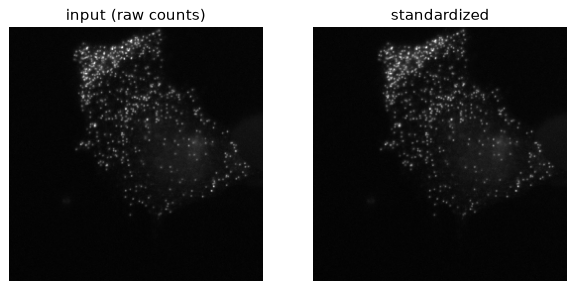

raw range [636, 9238]   standardized range [-0.77, 13.94]


In [2]:
x = mp.adjust(gray.astype(np.float32), meta["adjustment"])

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(gray, cmap="gray"); axs[0].set_title("input (raw counts)"); axs[0].axis("off")
axs[1].imshow(x, cmap="gray"); axs[1].set_title("standardized"); axs[1].axis("off")
plt.show()
print(f"raw range [{gray.min():.0f}, {gray.max():.0f}]   standardized range [{x.min():.2f}, {x.max():.2f}]")

## 2. Encoder — EfficientNetV2, four stages

`enc.stem` doesn't downsample; a 2x2 max-pool sits *between* each stage, so the
four levels end up at `[1, 1/2, 1/4, 1/8]` of the input resolution with
`[32, 64, 128, 256]` channels. Stages 0-1 are `FusedMBConv` (a single fused
expand+depthwise 3x3 conv); stages 2-3 are `MBConv` with squeeze-excite (1x1
expand, 3x3 depthwise, global-context gate, 1x1 project) — the deeper stages get
both more channels and a per-channel attention gate.

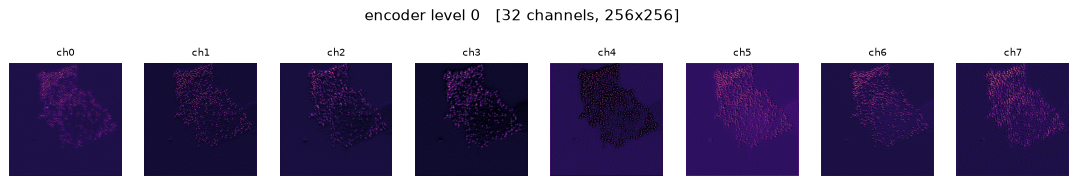

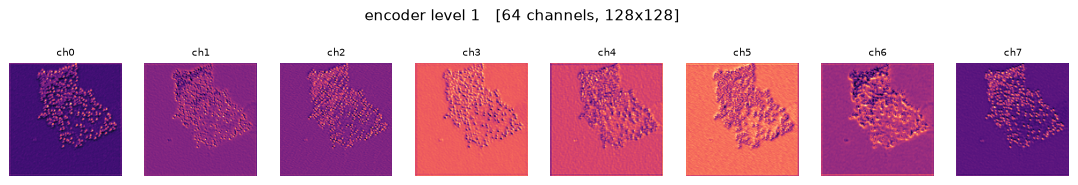

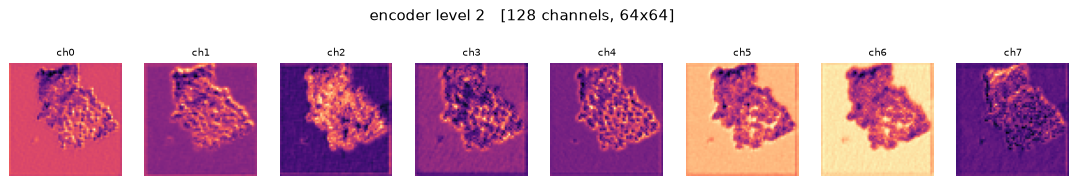

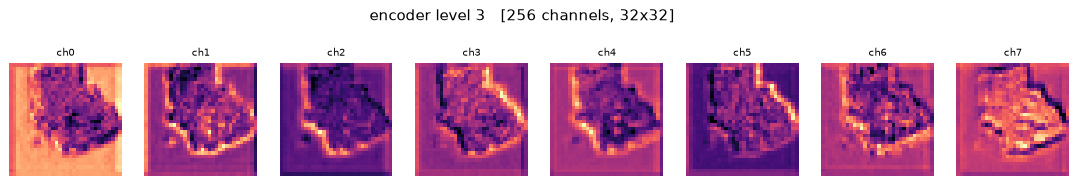

In [3]:
xd = mp.encoder_forward(W, x[None])
for i, feat in enumerate(xd):
    show_channels(feat, title=f"encoder level {i}")

## 3. Style vector + multi-scale FPN decoder

Exactly like `mini_cellpose.py`'s CPnet: a global-average-pooled, L2-normalized
**style vector** from the coarsest encoder level is projected into every decoder
block (FiLM-style conditioning — "here's what the whole image looks like",
injected alongside the local receptive field). The decoder then refines each of
the 4 encoder levels with its own `upconv` block, upsamples every level except
the finest the rest of the way to full resolution through a short chain of
extra `upconv`s, and **sums all four full-resolution results** — a multi-scale
merge, where Cellpose's decoder has a single top-down path.

style vector: (256,), ||style|| = 1.000


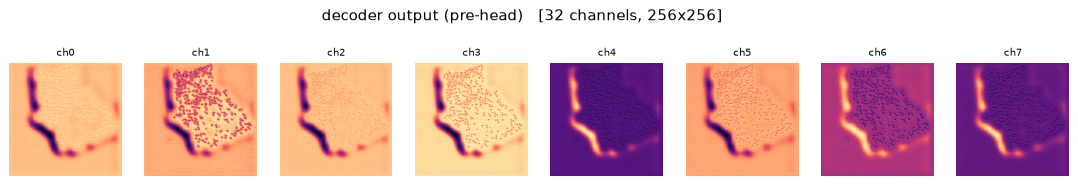

In [4]:
style = mp.make_style(xd[3])
print(f"style vector: {style.shape}, ||style|| = {np.linalg.norm(style):.3f}")

feat = mp.decoder_forward(W, style, xd)
show_channels(feat, title="decoder output (pre-head)")

## 4. Output head — label confidence + subpixel displacement

A single 1x1 conv turns the 32-channel decoder output into 3 channels: a label
*logit* (→ sigmoid → confidence that a spot center is near this pixel) and 2
*displacement* channels (row, col) pointing from this pixel toward the nearest
spot's true sub-pixel center. Confidence is diffuse — many pixels around each
spot light up — which is exactly the problem deformable pooling solves next.

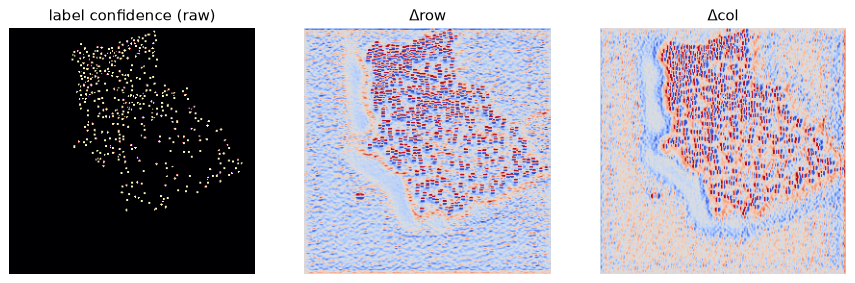

raw confidence range [0.000, 1.000]


In [5]:
out = mp.batchconv(W, "dec.out", feat)
labels_raw = mp.sigmoid(out[0])
deltas = out[1:]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(labels_raw, cmap="magma"); axs[0].set_title("label confidence (raw)"); axs[0].axis("off")
axs[1].imshow(deltas[0], cmap="coolwarm", vmin=-1, vmax=1); axs[1].set_title("Δrow"); axs[1].axis("off")
axs[2].imshow(deltas[1], cmap="coolwarm", vmin=-1, vmax=1); axs[2].set_title("Δcol"); axs[2].axis("off")
plt.show()
print(f"raw confidence range [{labels_raw.min():.3f}, {labels_raw.max():.3f}]")

## 5. Deformable max pooling

Every pixel rounds `its own position + its predicted displacement` to a target
pixel and votes for it; each pixel's *pooled* confidence is the max raw
confidence among everyone who voted for it (see `deformable_max_pool` — a
`kernel_size x kernel_size` windowed vote, `kernel_size = 2*dilation_iterations+1
= 3` for this checkpoint). Zoom into one crowded region: the raw confidence is a
diffuse cloud around each spot; pooling collapses each cloud to an isolated
single-pixel peak.

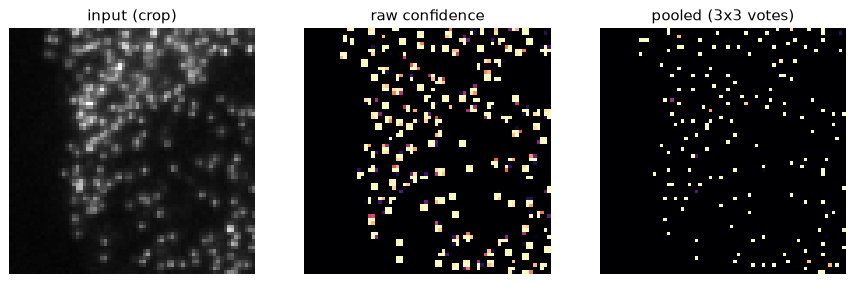

nonzero pixels: raw 628 -> pooled 164 (crop)


In [6]:
kernel_size = 2 * meta["dilation_iterations"] + 1
pooled = mp.deformable_max_pool(labels_raw, deltas, kernel_size)

cy, cx, sz = 60, 90, 35   # a crowded crop
sl = (slice(cy - sz, cy + sz), slice(cx - sz, cx + sz))

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(gray[sl], cmap="gray"); axs[0].set_title("input (crop)"); axs[0].axis("off")
axs[1].imshow(labels_raw[sl], cmap="magma"); axs[1].set_title("raw confidence"); axs[1].axis("off")
axs[2].imshow(pooled[sl], cmap="magma"); axs[2].set_title(f"pooled ({kernel_size}x{kernel_size} votes)"); axs[2].axis("off")
plt.show()
print(f"nonzero pixels: raw {int((labels_raw[sl] > 0.01).sum())} -> pooled {int((pooled[sl] > 0.01).sum())} (crop)")

## 6. Peak finding + subpixel coordinates

`peak_local_max` (a from-scratch equivalent of `skimage.feature.peak_local_max`:
separable max-filter for candidate local maxima, then greedy Chebyshev-distance
suppression) picks the surviving peaks above `threshold`. Each peak's own
predicted displacement is added back to its integer pixel position — that's
where the *subpixel* precision comes from; the network doesn't just say "a spot
is near pixel (12, 34)", it says "the spot is at (11.7, 34.2)".

417 peaks above confidence 0.5


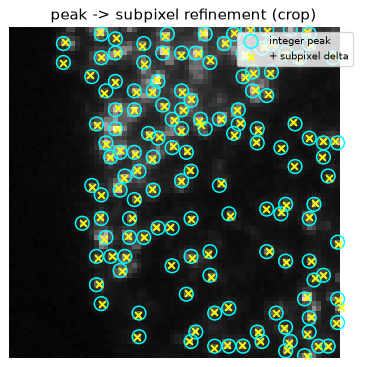

In [7]:
peaks = mp.peak_local_max(pooled, min_distance=MIN_DISTANCE, threshold_abs=THRESHOLD)
coords = mp.compute_spot_coordinates(pooled, deltas, THRESHOLD, MIN_DISTANCE)
print(f"{len(peaks)} peaks above confidence {THRESHOLD}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(gray[sl], cmap="gray")
crop_peaks = peaks[(peaks[:, 0] >= cy - sz) & (peaks[:, 0] < cy + sz) &
                    (peaks[:, 1] >= cx - sz) & (peaks[:, 1] < cx + sz)] - [cy - sz, cx - sz]
crop_coords = coords[(coords[:, 0] >= cy - sz) & (coords[:, 0] < cy + sz) &
                      (coords[:, 1] >= cx - sz) & (coords[:, 1] < cx + sz)] - [cy - sz, cx - sz]
plot_spots(ax, crop_peaks, s=120, facecolors="none", edgecolors="cyan", linewidths=1.2, label="integer peak")
plot_spots(ax, crop_coords, s=30, c="yellow", marker="x", label="+ subpixel delta")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("peak -> subpixel refinement (crop)"); ax.axis("off")
plt.show()

## 7. The whole pipeline, and how it compares to ground truth

`mini_piscis.detect_spots` does everything above in one call: standardize →
encoder → style → decoder → output head → deformable pool → peak find → subpixel
refine. This sample crop ships with Piscis's own manually-annotated ground-truth
spots, so we can compare directly — no cell segmentation "AP@IoU" metric here,
just points on top of points.

==> 417 predicted spots   (429 ground-truth annotations)


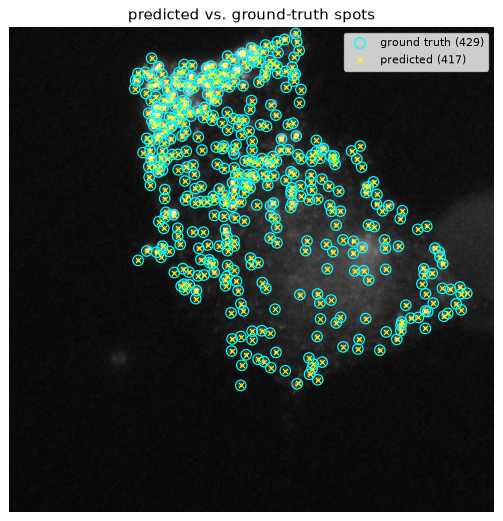

In [8]:
coords = mp.detect_spots(W, meta, gray, threshold=THRESHOLD, min_distance=MIN_DISTANCE, verbose=False)
print(f"==> {len(coords)} predicted spots   ({len(ground_truth)} ground-truth annotations)")

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(gray, cmap="gray", vmax=np.percentile(gray, 99.5))
plot_spots(ax, ground_truth, s=70, facecolors="none", edgecolors="cyan", linewidths=1.0, label=f"ground truth ({len(ground_truth)})")
plot_spots(ax, coords, s=18, c="yellow", marker="x", linewidths=0.8, label=f"predicted ({len(coords)})")
ax.legend(loc="upper right", fontsize=9)
ax.set_title("predicted vs. ground-truth spots"); ax.axis("off")
plt.show()

## That's the whole pipeline

**standardize → EfficientNetV2 encoder → style vector → multi-scale FPN decoder
→ (confidence, displacement) → deformable max pool → peak find → subpixel
refine.** No instance labels, no NMS-by-overlap, no iterative dynamics — just a
learned displacement field and a pooling operation shaped around it.

Validated against the real PyTorch model on all three bundled samples: the
forward pass matches to **max|Δ| < 1e-5**, and the final subpixel coordinates
(peak finding + delta refinement, entirely hand-rolled — no skimage) match
**exactly in count and to < 1e-5 px** (`python mini_piscis.py <img> --validate`).
Compare `mini_cellpose_walkthrough.ipynb` for the closest relative: `mini_
piscis.py`'s `batchconv`/`upconv` are the same idea as Cellpose's `batchconv`/
`res_up`, aimed at a different target — a point instead of a region.